# Analyze Training Run

Use this notebook to inspect a training run directory or checkpoint file, plot curves, and get troubleshooting advice when artifacts are missing.

In [12]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
except Exception as e:
    yaml = None
    warnings.warn(f"PyYAML import failed: {e}")

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)


In [13]:
# Run target. Can be either:
# - run directory: src/models/saved_weights/<run_name>
# - checkpoint file: src/models/saved_weights/<run_name>/best_val.pt
RUN_INPUT = 'src/models/saved_weights/irmas_single_label_mel_densenet_121'
PREFERRED_WEIGHT = 'best_val.pt'

# Optional: set this if your notebook kernel cwd is not project root.
# Example: '/Users/hughsignoriello/Developer/ml-based-analysis-of-sound'
PROJECT_ROOT_HINT: str | None = None


In [14]:
def find_project_root(cwd: Path, hint: str | None = None) -> Path:
    markers = [Path('src/configs/audio_params.yaml'), Path('.git')]

    if hint:
        hp = Path(hint).expanduser().resolve()
        if hp.exists() and (hp / 'src/configs/audio_params.yaml').exists():
            return hp

    here = cwd.resolve()
    for base in [here, *here.parents]:
        if (base / markers[0]).exists() or (base / markers[1]).exists():
            return base
    return here


def resolve_input_path(path_like: str | Path, project_root: Path) -> tuple[Path, list[Path]]:
    p = Path(path_like).expanduser()
    if p.is_absolute():
        return p.resolve(), [p.resolve()]

    candidates = [
        (Path.cwd() / p).resolve(),
        (project_root / p).resolve(),
    ]

    # Preserve order while deduplicating
    uniq = []
    seen = set()
    for c in candidates:
        key = str(c)
        if key not in seen:
            uniq.append(c)
            seen.add(key)

    for c in uniq:
        if c.exists():
            return c, uniq

    return uniq[0], uniq


def resolve_run_and_checkpoint(
    run_input: str | Path,
    preferred_weight: str = 'best_val.pt',
    project_root_hint: str | None = None,
) -> dict[str, Any]:
    project_root = find_project_root(Path.cwd(), project_root_hint)
    resolved_input, tried = resolve_input_path(run_input, project_root)

    if not resolved_input.exists():
        tried_msg = '\n'.join([f'- {x}' for x in tried])
        raise FileNotFoundError(
            f"RUN_INPUT does not exist: {run_input}\n"
            f"Working directory: {Path.cwd()}\n"
            f"Project root guess: {project_root}\n"
            f"Tried:\n{tried_msg}"
        )

    if resolved_input.is_file():
        if resolved_input.suffix != '.pt':
            raise ValueError(f"Expected .pt checkpoint file, got: {resolved_input}")
        run_dir = resolved_input.parent
        ckpt_path = resolved_input
    else:
        run_dir = resolved_input
        preferred = run_dir / preferred_weight
        best = run_dir / 'best_val.pt'
        last = run_dir / 'last.pt'

        if preferred.exists():
            ckpt_path = preferred
        elif best.exists():
            ckpt_path = best
        elif last.exists():
            ckpt_path = last
        else:
            ckpt_path = None

    return {
        'project_root': project_root,
        'resolved_input': resolved_input,
        'run_dir': run_dir,
        'ckpt_path': ckpt_path,
        'run_cfg_path': run_dir / 'run_config.yaml',
        'history_csv_path': run_dir / 'history.csv',
        'split_path': run_dir / 'split_indices.pt',
    }


def load_run_config(path: Path) -> dict:
    if not path.exists() or yaml is None:
        return {}
    with open(path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f) or {}


def history_dict_to_df(history: dict) -> pd.DataFrame:
    if not isinstance(history, dict) or not history:
        return pd.DataFrame()

    values = {k: v for k, v in history.items() if isinstance(v, list)}
    if not values:
        return pd.DataFrame()

    max_len = max(len(v) for v in values.values())
    for k, v in values.items():
        if len(v) < max_len:
            values[k] = v + [np.nan] * (max_len - len(v))

    return pd.DataFrame(values)


def load_history(history_csv_path: Path, ckpt_path: Path | None):
    notes: list[str] = []

    if history_csv_path.exists():
        return pd.read_csv(history_csv_path), 'history.csv', notes

    notes.append(f'Missing history.csv: {history_csv_path}')

    if ckpt_path is None:
        notes.append('No checkpoint found (best_val.pt / last.pt).')
        return pd.DataFrame(), 'none', notes

    try:
        import torch

        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        history_df = history_dict_to_df(ckpt.get('history', {}))
        if history_df.empty:
            notes.append(f'Checkpoint loaded but history payload empty: {ckpt_path}')
            return history_df, f'checkpoint:{ckpt_path.name}', notes
        return history_df, f'checkpoint:{ckpt_path.name}', notes
    except Exception as e:
        notes.append(f'Failed to read checkpoint history from {ckpt_path}: {e}')
        return pd.DataFrame(), 'none', notes


In [15]:
advisor: list[str] = []
resolved = None
run_cfg = {}
history_df = pd.DataFrame()
history_source = 'none'

try:
    resolved = resolve_run_and_checkpoint(RUN_INPUT, PREFERRED_WEIGHT, PROJECT_ROOT_HINT)
    run_cfg = load_run_config(resolved['run_cfg_path'])
    history_df, history_source, notes = load_history(resolved['history_csv_path'], resolved['ckpt_path'])
    advisor.extend(notes)
except Exception as e:
    advisor.append(str(e))

if resolved is None:
    summary = {
        'status': 'error',
        'run_dir': 'n/a',
        'checkpoint': 'n/a',
        'history_source': history_source,
        'history_rows': 0,
    }
else:
    summary = {
        'status': 'ok' if not history_df.empty else 'warning',
        'project_root': str(resolved['project_root']),
        'resolved_input': str(resolved['resolved_input']),
        'run_dir': str(resolved['run_dir']),
        'checkpoint': str(resolved['ckpt_path']) if resolved['ckpt_path'] else 'not found',
        'history_source': history_source,
        'history_rows': int(len(history_df)),
        'task_mode': run_cfg.get('task_mode', 'unknown'),
        'feature_mode': run_cfg.get('feature_mode', 'unknown'),
        'dataset': run_cfg.get('dataset', 'unknown'),
        'experiment_name': run_cfg.get('experiment_name', 'unknown'),
        'backbone': ((run_cfg.get('model') or {}).get('backbone', 'unknown')),
    }

pd.DataFrame([summary]).T.rename(columns={0: 'value'})


,value
status,ok
project_root,/Users/hughsignoriello/Developer/ml-based-anal...
resolved_input,/Users/hughsignoriello/Developer/ml-based-anal...
run_dir,/Users/hughsignoriello/Developer/ml-based-anal...
checkpoint,/Users/hughsignoriello/Developer/ml-based-anal...
history_source,history.csv
history_rows,50
task_mode,single_label
feature_mode,mel
dataset,irmas


In [16]:
if advisor:
    print('Troubleshooting notes:')
    for msg in advisor:
        print(f'- {msg}')

if history_df.empty:
    print('\nNo plottable training history available yet.')
    print('Fix checklist:')
    print('1) Confirm RUN_INPUT points to the correct run directory or .pt checkpoint.')
    print('2) Prefer a run with history.csv (produced after training completes).')
    print('3) If using checkpoint fallback, ensure torch imports in this kernel.')
    print('4) If torch load fails with OMP/shared-memory errors, run the notebook in the same local env used for training.')


In [17]:
if not history_df.empty:
    history_df = history_df.copy()
    if 'epoch' not in history_df.columns:
        history_df.insert(0, 'epoch', np.arange(1, len(history_df) + 1))

    for c in history_df.columns:
        if c != 'epoch':
            history_df[c] = pd.to_numeric(history_df[c], errors='coerce')

history_df.head() if not history_df.empty else pd.DataFrame({'info': ['history unavailable']})


,epoch,train_acc,train_loss,train_macro_f1,train_micro_f1,val_acc,val_loss,val_macro_f1,val_micro_f1
0,1,0.380306,1.780845,0.332525,0.380306,0.433621,1.679047,0.396348,0.433621
1,2,0.515622,1.412115,0.504000,0.515622,0.558621,1.334758,0.544648,0.558621
2,3,0.590605,1.191224,0.583829,0.590605,0.581897,1.259370,0.554061,0.581897
3,4,0.653092,1.025646,0.646448,0.653092,0.565517,1.333420,0.553644,0.565517
4,5,0.703943,0.888826,0.696738,0.703943,0.662069,1.068743,0.651221,0.662069


In [18]:
diagnostics = {}
if not history_df.empty and 'val_loss' in history_df.columns:
    best_idx = int(history_df['val_loss'].idxmin())
    best_row = history_df.loc[best_idx]
    diagnostics['best_epoch_by_val_loss'] = int(best_row['epoch'])
    diagnostics['best_val_loss'] = float(best_row['val_loss'])

if not history_df.empty:
    for metric in ('val_macro_f1', 'val_micro_f1', 'val_acc'):
        if metric in history_df.columns:
            idx = int(history_df[metric].idxmax())
            diagnostics[f'best_{metric}'] = float(history_df.loc[idx, metric])
            diagnostics[f'best_{metric}_epoch'] = int(history_df.loc[idx, 'epoch'])

pd.DataFrame([diagnostics]).T.rename(columns={0: 'value'}) if diagnostics else pd.DataFrame({'info': ['No diagnostics available']})


,value
best_epoch_by_val_loss,38.000000
best_val_loss,0.597671
best_val_macro_f1,0.860736
best_val_macro_f1_epoch,49.000000
best_val_micro_f1,0.861207
best_val_micro_f1_epoch,49.000000
best_val_acc,0.861207
best_val_acc_epoch,49.000000


In [19]:
def pair_train_val_metrics(columns):
    pairs = []
    seen = set()
    for c in columns:
        if c.startswith('train_'):
            base = c[len('train_'):]
            vc = f'val_{base}'
            if vc in columns and base not in seen:
                pairs.append((base, c, vc))
                seen.add(base)
    return pairs

pairs = pair_train_val_metrics(history_df.columns) if not history_df.empty else []
pairs


[('acc', 'train_acc', 'val_acc'),
 ('loss', 'train_loss', 'val_loss'),
 ('macro_f1', 'train_macro_f1', 'val_macro_f1'),
 ('micro_f1', 'train_micro_f1', 'val_micro_f1')]

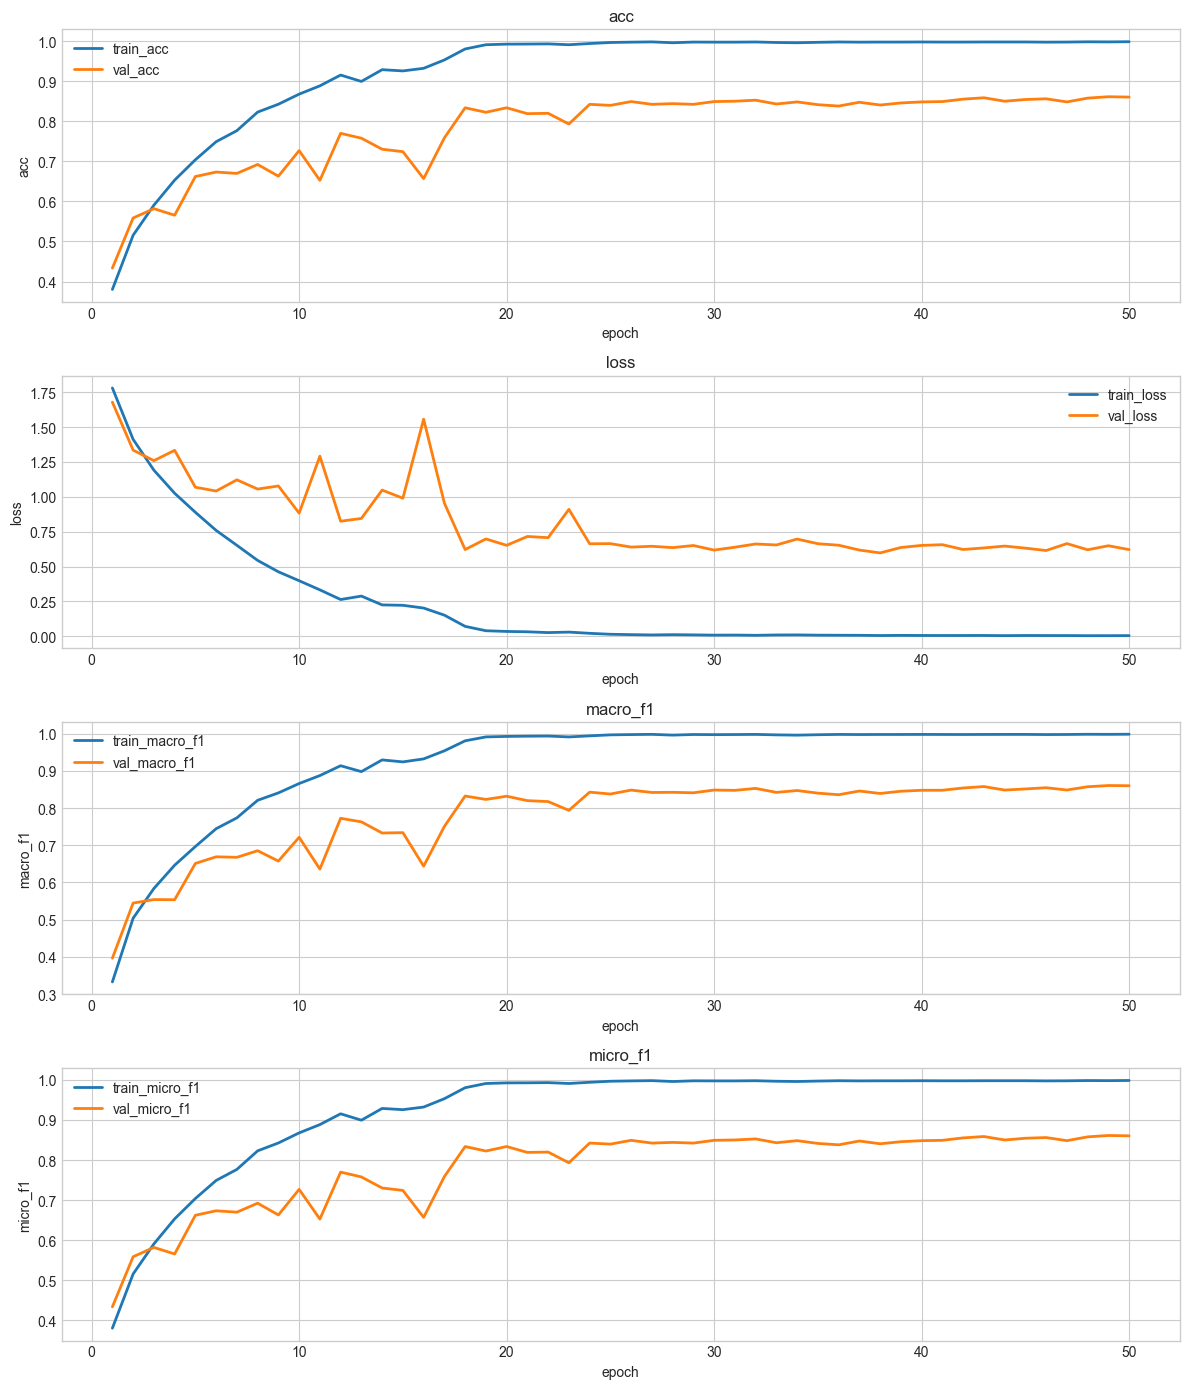

In [20]:
if history_df.empty:
    print('Skipping plots: history unavailable.')
elif not pairs:
    print('Skipping plots: no train_/val_ metric pairs in history.')
else:
    n = len(pairs)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, max(3.5 * n, 4)), squeeze=False)

    for i, (base, train_col, val_col) in enumerate(pairs):
        ax = axes[i, 0]
        ax.plot(history_df['epoch'], history_df[train_col], label=train_col, linewidth=2)
        ax.plot(history_df['epoch'], history_df[val_col], label=val_col, linewidth=2)
        ax.set_title(base)
        ax.set_xlabel('epoch')
        ax.set_ylabel(base)
        ax.legend(loc='best')

    plt.tight_layout()
    plt.show()
